In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

print("="*50)
print("Libraries Imported Successfully")
print("="*50)

Libraries Imported Successfully


In [113]:
df = pd.read_csv("../data/smart_city_thiranex_cleaned.csv")


print("="*50)
print(" Dataset Loaded Successfully")
print("="*50)
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])
print("Dataset Loaded..")

 Dataset Loaded Successfully
Number of Rows    : 10000
Number of Columns : 15
Dataset Loaded..


In [114]:
print("\nFirst 5 Rows")
print(df.head())


First 5 Rows
   Incident_ID Incident_Type     Area Time_of_Day Day_of_Week Weather  \
0            1         Theft  Central     Morning      Friday   Rainy   
1            2       Medical    South       Night     Tuesday   Rainy   
2            3      Accident    South   Afternoon      Sunday   Rainy   
3            4         Theft     West     Morning    Thursday   Sunny   
4            5         Theft    South     Evening      Monday   Sunny   

  Crowd_Level CCTV_Available  Police_Response_Time  Ambulance_Response_Time  \
0         Low            Yes                  10.0                       12   
1        High             No                  19.0                       24   
2         Low            Yes                  25.0                       18   
3        High             No                  14.0                       24   
4         Low             No                  21.0                       11   

   Fire_Response_Time  Number_of_People  Severity_Score  Previous_Incide

In [115]:
print("="*50)
print("Dataset Information")
print("="*50)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Incident_ID              10000 non-null  int64  
 1   Incident_Type            10000 non-null  str    
 2   Area                     10000 non-null  str    
 3   Time_of_Day              10000 non-null  str    
 4   Day_of_Week              10000 non-null  str    
 5   Weather                  10000 non-null  str    
 6   Crowd_Level              10000 non-null  str    
 7   CCTV_Available           10000 non-null  str    
 8   Police_Response_Time     10000 non-null  float64
 9   Ambulance_Response_Time  10000 non-null  int64  
 10  Fire_Response_Time       10000 non-null  int64  
 11  Number_of_People         10000 non-null  int64  
 12  Severity_Score           10000 non-null  int64  
 13  Previous_Incidents       10000 non-null  int64  
 14  Emergency_Leve

In [116]:
print("="*50)
print("Dataset Shape")
print("="*50)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Dataset Shape
Rows : 10000
Columns : 15


In [117]:
print("="*50)
print("Missing Values")
print("="*50)

print(df.isnull().sum())

Missing Values
Incident_ID                0
Incident_Type              0
Area                       0
Time_of_Day                0
Day_of_Week                0
Weather                    0
Crowd_Level                0
CCTV_Available             0
Police_Response_Time       0
Ambulance_Response_Time    0
Fire_Response_Time         0
Number_of_People           0
Severity_Score             0
Previous_Incidents         0
Emergency_Level            0
dtype: int64


In [118]:
print("="*50)
print("Duplicate Rows")
print("="*50)

print(df.duplicated().sum())

Duplicate Rows
0


In [119]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Label Encoding Completed")

Label Encoding Completed


C:\Users\MATHUMITHA\AppData\Local\Temp\ipykernel_10952\3250034544.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [120]:
X = df.drop(["Incident_ID", "Emergency_Level"], axis=1)

y = df["Emergency_Level"]

print("="*50)
print("Features and Target Created")
print("="*50)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

Features and Target Created
X Shape : (10000, 13)
y Shape : (10000,)


In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*50)
print("Train Test Split Completed")
print("="*50)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Train Test Split Completed
Training Samples : (8000, 13)
Testing Samples : (2000, 13)


In [122]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("="*50)
print("Feature Scaling Completed")
print("="*50)

Feature Scaling Completed


In [123]:
print("="*50)
print("Training Logistic Regression Model")
print("="*50)

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Training Logistic Regression Model


Logistic Regression Model Trained Successfully


In [124]:
print("="*50)
print("Logistic Regression Performance")
print("="*50)

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr, average='weighted'))
print("Recall :", recall_score(y_test, pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, pred_lr, average='weighted'))

print("\nClassification Report\n")
print(classification_report(y_test, pred_lr))

Logistic Regression Performance
Accuracy : 0.9925
Precision : 0.9924771376556262
Recall : 0.9925
F1 Score : 0.9924405268469878

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1498
           1       0.99      0.93      0.96       105
           2       0.98      0.98      0.98       397

    accuracy                           0.99      2000
   macro avg       0.99      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000



In [125]:
print("="*50)
print("Training Decision Tree Model")
print("="*50)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Model Trained Successfully")

Training Decision Tree Model


Decision Tree Model Trained Successfully


In [126]:
print("="*50)
print("Decision Tree Performance")
print("="*50)

print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision :", precision_score(y_test, pred_dt, average='weighted'))
print("Recall :", recall_score(y_test, pred_dt, average='weighted'))
print("F1 Score :", f1_score(y_test, pred_dt, average='weighted'))

print("\nClassification Report\n")
print(classification_report(y_test, pred_dt))

Decision Tree Performance
Accuracy : 0.9685
Precision : 0.968420895785676
Recall : 0.9685
F1 Score : 0.9684351035429009

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1498
           1       0.91      0.93      0.92       105
           2       0.93      0.91      0.92       397

    accuracy                           0.97      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.97      0.97      0.97      2000



In [127]:
print("="*50)
print("Training Random Forest Model")
print("="*50)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Training Random Forest Model
Random Forest Model Trained Successfully


In [128]:
print("="*50)
print("Random Forest Performance")
print("="*50)

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf, average='weighted'))
print("Recall :", recall_score(y_test, pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, pred_rf, average='weighted'))

print("\nClassification Report\n")
print(classification_report(y_test, pred_rf))

Random Forest Performance
Accuracy : 0.9565
Precision : 0.9564426081833396
Recall : 0.9565
F1 Score : 0.9553214312297804

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1498
           1       1.00      0.75      0.86       105
           2       0.91      0.87      0.89       397

    accuracy                           0.96      2000
   macro avg       0.96      0.87      0.91      2000
weighted avg       0.96      0.96      0.96      2000



In [129]:
print("="*50)
print("Training SVM Model")
print("="*50)

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Model Trained Successfully")

Training SVM Model


C:\Users\MATHUMITHA\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Model Trained Successfully


In [130]:
print("="*50)
print("SVM Performance")
print("="*50)

print("Accuracy :", accuracy_score(y_test, pred_svm))
print("Precision :", precision_score(y_test, pred_svm, average='weighted'))
print("Recall :", recall_score(y_test, pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, pred_svm, average='weighted'))

print("\nClassification Report\n")
print(classification_report(y_test, pred_svm))

SVM Performance
Accuracy : 0.968
Precision : 0.9679262301129934
Recall : 0.968
F1 Score : 0.967488497474418

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1498
           1       0.95      0.78      0.86       105
           2       0.91      0.93      0.92       397

    accuracy                           0.97      2000
   macro avg       0.95      0.90      0.92      2000
weighted avg       0.97      0.97      0.97      2000



In [131]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_svm)
    ],

    "Precision":[
        precision_score(y_test,pred_lr,average='weighted'),
        precision_score(y_test,pred_dt,average='weighted'),
        precision_score(y_test,pred_rf,average='weighted'),
        precision_score(y_test,pred_svm,average='weighted')
    ],

    "Recall":[
        recall_score(y_test,pred_lr,average='weighted'),
        recall_score(y_test,pred_dt,average='weighted'),
        recall_score(y_test,pred_rf,average='weighted'),
        recall_score(y_test,pred_svm,average='weighted')
    ],

    "F1 Score":[
        f1_score(y_test,pred_lr,average='weighted'),
        f1_score(y_test,pred_dt,average='weighted'),
        f1_score(y_test,pred_rf,average='weighted'),
        f1_score(y_test,pred_svm,average='weighted')
    ]

})

print("="*50)
print("Model Comparison")
print("="*50)

results

Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9925,0.992477,0.9925,0.992441
1,Decision Tree,0.9685,0.968421,0.9685,0.968435
2,Random Forest,0.9565,0.956443,0.9565,0.955321
3,SVM,0.9680,0.967926,0.9680,0.967488


Accuracy Comparison Graph


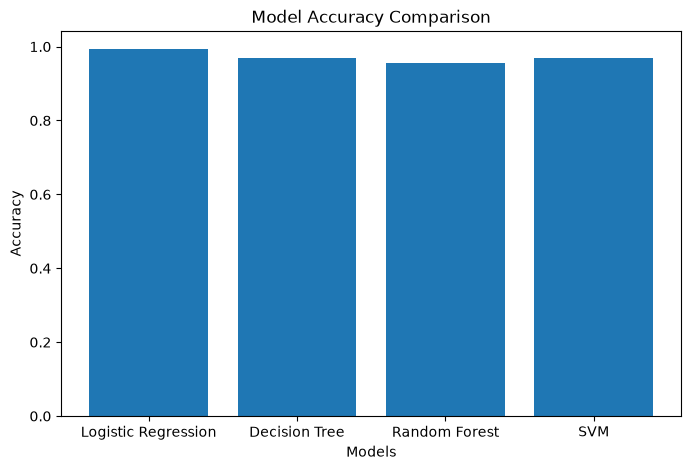

In [132]:
print("="*50)
print("Accuracy Comparison Graph")
print("="*50)

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

Random Forest Confusion Matrix


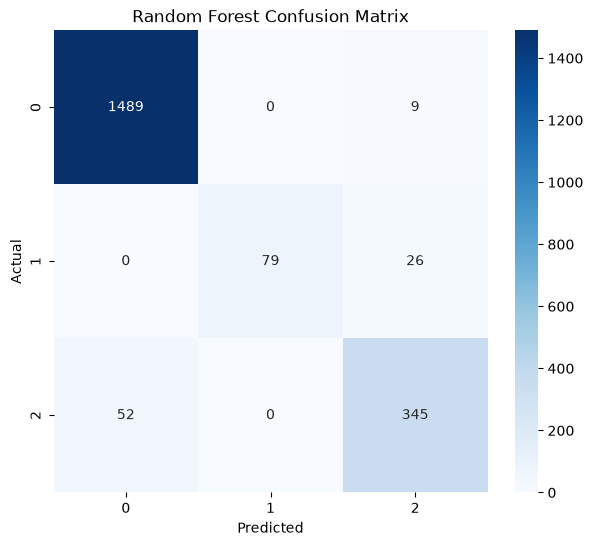

In [133]:
print("="*50)
print("Random Forest Confusion Matrix")
print("="*50)

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [134]:
print("="*50)
print("Saving Best Model")
print("="*50)

joblib.dump(rf,"../models/smart_city_model.pkl")

print("Model Saved Successfully")

Saving Best Model
Model Saved Successfully


In [135]:
print("="*50)
print("Best Model")
print("="*50)

best_model = results.loc[
    results["Accuracy"].idxmax()
]

print(best_model)

Best Model
Model        Logistic Regression
Accuracy                  0.9925
Precision               0.992477
Recall                    0.9925
F1 Score                0.992441
Name: 0, dtype: object
